In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('../data/popular_movies.csv')
df.head(5)

,title,budget,genres,original_language,overview,popularity,poster_path,release_date,revenue,runtime,spoken_languages,vote_average,vote_count,production_companies,production_countries
0,Final Destination Bloodlines,50000000,"[{'id': 27, 'name': 'Horror'}, {'id': 9648, 'n...",en,"Plagued by a violent recurring nightmare, coll...",1179.7021,/6WxhEvFsauuACfv8HyoVX6mZKFj.jpg,2025-05-14,274218717,110,"[{'english_name': 'English', 'iso_639_1': 'en'...",7.218,1035,"[{'id': 12, 'logo_path': '/2ycs64eqV5rqKYHyQK0...","[{'iso_3166_1': 'US', 'name': 'United States o..."
1,Lilo & Stitch,100000000,"[{'id': 10751, 'name': 'Family'}, {'id': 878, ...",en,The wildly funny and touching story of a lonel...,412.5716,/c32TsWLES7kL1uy6fF03V67AIYX.jpg,2025-05-17,864080503,108,"[{'english_name': 'English', 'iso_639_1': 'en'...",7.100,677,"[{'id': 2, 'logo_path': '/wdrCwmRnLFJhEoH8GSfy...","[{'iso_3166_1': 'US', 'name': 'United States o..."
2,STRAW,0,"[{'id': 53, 'name': 'Thriller'}, {'id': 18, 'n...",en,What will be her last straw? A devastatingly b...,345.6187,/t3cmnXYtxJb9vVL1ThvT2CWSe1n.jpg,2025-06-05,0,105,"[{'english_name': 'English', 'iso_639_1': 'en'...",8.048,556,"[{'id': 3096, 'logo_path': '/fkZTZ4veYYr3lwr2r...","[{'iso_3166_1': 'US', 'name': 'United States o..."
3,The Amateur,60000000,"[{'id': 53, 'name': 'Thriller'}, {'id': 28, 'n...",en,After his life is turned upside down when his ...,334.9235,/SNEoUInCa5fAgwuEBMIMBGvkkh.jpg,2025-04-09,95956038,123,"[{'english_name': 'English', 'iso_639_1': 'en'...",6.929,560,"[{'id': 127928, 'logo_path': '/h0rjX5vjW5r8yEn...","[{'iso_3166_1': 'US', 'name': 'United States o..."
4,How to Train Your Dragon,150000000,"[{'id': 28, 'name': 'Action'}, {'id': 10751, '...",en,"On the rugged isle of Berk, where Vikings and ...",349.6505,/q5pXRYTycaeW6dEgsCrd4mYPmxM.jpg,2025-06-06,236807059,125,"[{'english_name': 'English', 'iso_639_1': 'en'...",8.000,334,"[{'id': 521, 'logo_path': '/kP7t6RwGz2AvvTkvnI...","[{'iso_3166_1': 'US', 'name': 'United States o..."


<h2>Data Exploration & Understanding<h2>

In [3]:
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nFirst few rows:\n{df.head()}")


Dataset shape: (9999, 15)

Columns: ['title', 'budget', 'genres', 'original_language', 'overview', 'popularity', 'poster_path', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'vote_average', 'vote_count', 'production_companies', 'production_countries']

Data types:
title                    object
budget                    int64
genres                   object
original_language        object
overview                 object
popularity              float64
poster_path              object
release_date             object
revenue                   int64
runtime                   int64
spoken_languages         object
vote_average            float64
vote_count                int64
production_companies     object
production_countries     object
dtype: object

Missing values:
title                    0
budget                   0
genres                   0
original_language        0
overview                93
popularity               0
poster_path             58
release_date           

<h2>Data Cleaning</h2>

In [4]:
# Check for duplicates
print(f"Duplicate rows: {df.duplicated().sum()}")

# Check data quality issues
print(f"\nBudget stats:")
print(f"Zero budget movies: {(df['budget'] == 0).sum()}")
print(f"Budget range: ${df['budget'].min():,} to ${df['budget'].max():,}")

print(f"\nRevenue stats:")
print(f"Zero revenue movies: {(df['revenue'] == 0).sum()}")
print(f"Revenue range: ${df['revenue'].min():,} to ${df['revenue'].max():,}")

print(f"\nRuntime stats:")
print(f"Zero runtime movies: {(df['runtime'] == 0).sum()}")
print(f"Runtime range: {df['runtime'].min()} to {df['runtime'].max()} minutes")

# Check date format
print(f"\nRelease date sample: {df['release_date'].head()}")

Duplicate rows: 592

Budget stats:
Zero budget movies: 4666
Budget range: $0 to $465,400,000

Revenue stats:
Zero revenue movies: 4244
Revenue range: $0 to $2,923,706,026

Runtime stats:
Zero runtime movies: 222
Runtime range: 0 to 417 minutes

Release date sample: 0    2025-05-14
1    2025-05-17
2    2025-06-05
3    2025-04-09
4    2025-06-06
Name: release_date, dtype: object


In [5]:
# Remove duplicates
print(f"Before: {len(df)} rows")
df = df.drop_duplicates()
print(f"After duplicate removal: {len(df)} rows")

# Remove zero runtime movies (likely data errors)
df = df[df['runtime'] > 0]
print(f"After removing zero runtime: {len(df)} rows")

# Remove zero budget movies (likely data errors)
df = df[df['budget'] > 0]
print(f"After removing zero budget: {len(df)} rows")

# Convert release_date to datetime
df['release_date'] = pd.to_datetime(df['release_date'])
print(f"\nFinal clean dataset: {len(df)} rows")

df_clean = df.copy()

Before: 9999 rows
After duplicate removal: 9407 rows
After removing zero runtime: 9195 rows
After removing zero budget: 4995 rows

Final clean dataset: 4995 rows


<h4>Data Visualization</h4>

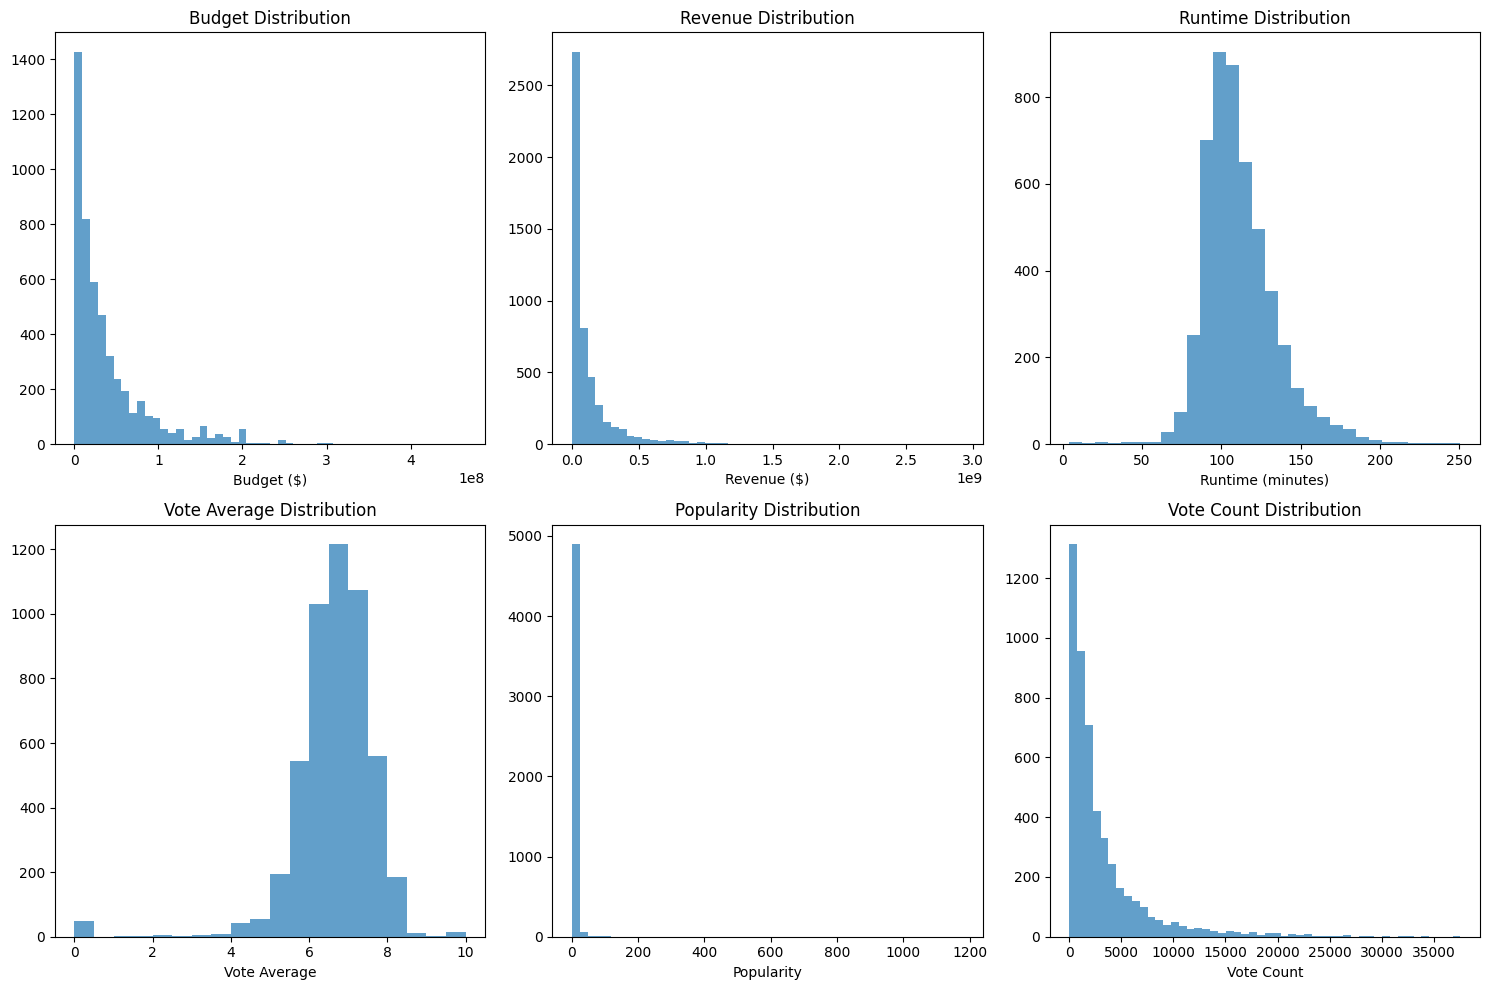

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up plotting
plt.style.use('default')
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Budget distribution
axes[0,0].hist(df_clean['budget'], bins=50, alpha=0.7)
axes[0,0].set_title('Budget Distribution')
axes[0,0].set_xlabel('Budget ($)')

# Revenue distribution
axes[0,1].hist(df_clean['revenue'], bins=50, alpha=0.7)
axes[0,1].set_title('Revenue Distribution')
axes[0,1].set_xlabel('Revenue ($)')

# Runtime distribution
axes[0,2].hist(df_clean['runtime'], bins=30, alpha=0.7)
axes[0,2].set_title('Runtime Distribution')
axes[0,2].set_xlabel('Runtime (minutes)')

# Vote average distribution
axes[1,0].hist(df_clean['vote_average'], bins=20, alpha=0.7)
axes[1,0].set_title('Vote Average Distribution')
axes[1,0].set_xlabel('Vote Average')

# Popularity distribution
axes[1,1].hist(df_clean['popularity'], bins=50, alpha=0.7)
axes[1,1].set_title('Popularity Distribution')
axes[1,1].set_xlabel('Popularity')

# Vote count distribution
axes[1,2].hist(df_clean['vote_count'], bins=50, alpha=0.7)
axes[1,2].set_title('Vote Count Distribution')
axes[1,2].set_xlabel('Vote Count')

plt.tight_layout()
plt.show()

<h4>Define Target Variable (Hit/Flop)</h4>

In [7]:
# Create ROI-based target variable
df_clean['roi'] = df_clean['revenue'] / (df_clean['budget'] + 1)  # +1 to avoid division by zero

# Define hit/flop threshold
roi_threshold = df_clean['roi'].quantile(0.7)  # Top 30% are hits
df_clean['is_hit'] = (df_clean['roi'] >= roi_threshold).astype(int)

print(f"ROI threshold: {roi_threshold:.2f}")
print(f"Hit distribution:")
print(df_clean['is_hit'].value_counts())
print(f"Hit percentage: {df_clean['is_hit'].mean()*100:.1f}%")

# Show some examples
print(f"\nSample hits and flops:")
print(df_clean[['title', 'budget', 'revenue', 'roi', 'is_hit']].head(10))

ROI threshold: 3.89
Hit distribution:
is_hit
0    3496
1    1499
Name: count, dtype: int64
Hit percentage: 30.0%

Sample hits and flops:
                           title     budget    revenue       roi  is_hit
0   Final Destination Bloodlines   50000000  274218717  5.484374       1
1                  Lilo & Stitch  100000000  864080503  8.640805       1
3                    The Amateur   60000000   95956038  1.599267       0
4       How to Train Your Dragon  150000000  236807059  1.578714       0
8                Hunt the Wicked    2107575          0  0.000000       0
10               The Accountant²   80000000  102123366  1.276542       0
14                       Sinners   90000000  361535673  4.017063       1
15                28 Years Later   60000000    5800000  0.096667       0
16             A Minecraft Movie  150000000  951514812  6.343432       1
19                        Kayara    8000000          0  0.000000       0


<h4>Feature Engineering</h4>

In [8]:
import json
from datetime import datetime

# Extract year from release date
df_clean['release_year'] = df_clean['release_date'].dt.year

# Create budget/revenue categories
df_clean['budget_category'] = pd.cut(df_clean['budget'], 
                                   bins=[0, 1000000, 50000000, 150000000, float('inf')], 
                                   labels=['Ultra_Low', 'Low', 'Medium', 'High'])

df_clean[['release_year','budget_category']].head(5)

,release_year,budget_category
0,2025,Low
1,2025,Medium
3,2025,Medium
4,2025,Medium
8,2024,Low


In [9]:
def extract_genres(genres_str):
    try:
        genres = json.loads(genres_str.replace("'", '"'))
        return len(genres), genres[0]['name'] if genres else 'Unknown'
    except:
        return 0, 'Unknown'

df_clean[['genre_count', 'main_genre']] = df_clean['genres'].apply(
    lambda x: pd.Series(extract_genres(x))
)

df_clean[['genre_count', 'main_genre']].head()

,genre_count,main_genre
0,2,Horror
1,4,Family
3,2,Thriller
4,3,Action
8,1,Action


In [10]:
# Language feature (English vs Non-English)
df_clean['is_english'] = (df_clean['original_language'] == 'en').astype(int)

print("New features created:")
print(f"Release year range: {df_clean['release_year'].min()}-{df_clean['release_year'].max()}")
print(f"Budget categories: {df_clean['budget_category'].value_counts()}")
print(f"Genre count range: {df_clean['genre_count'].min()}-{df_clean['genre_count'].max()}")
print(f"Main genres: {df_clean['main_genre'].value_counts().head()}")
print(f"English movies: {df_clean['is_english'].mean()*100:.1f}%")

New features created:
Release year range: 1920-2026
Budget categories: budget_category
Low          3421
Medium        998
Ultra_Low     359
High          217
Name: count, dtype: int64
Genre count range: 0-8
Main genres: main_genre
Action       940
Drama        938
Comedy       722
Horror       507
Adventure    365
Name: count, dtype: int64
English movies: 84.9%


<h4>Check correlation with target<h4>

In [ ]:
# Check feature correlation with target
corr_features = ['budget', 'revenue', 'runtime', 'vote_average', 'vote_count', 
                'popularity', 'genre_count', 'is_english', 'release_year']

correlations = df_clean[corr_features + ['is_hit']].corr()['is_hit'].sort_values(ascending=False)
print("Feature correlations with is_hit:")
print(correlations[:-1])

Feature correlations with is_hit:
is_hit          1.000000
revenue         0.341453
vote_count      0.328999
vote_average    0.219563
popularity      0.067076
runtime         0.054220
is_english      0.009737
budget         -0.075403
genre_count    -0.078087
Name: is_hit, dtype: float64


<h4>Exploratory Data Analysis</h4>

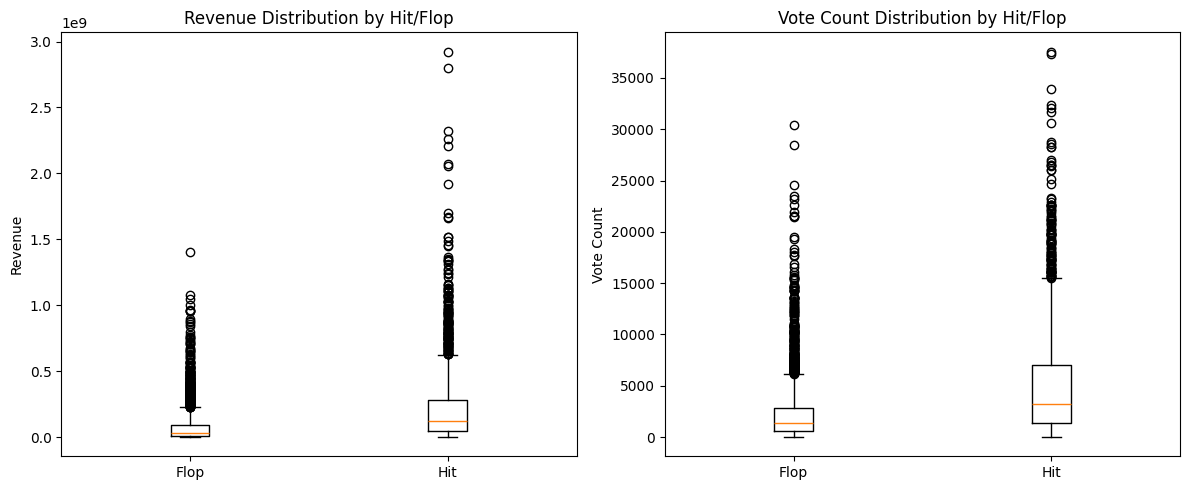

In [12]:
# Visualize key relationships
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Revenue vs Hit rate
axes[0].boxplot([df_clean[df_clean['is_hit']==0]['revenue'], 
                 df_clean[df_clean['is_hit']==1]['revenue']])
axes[0].set_xticklabels(['Flop', 'Hit'])
axes[0].set_ylabel('Revenue')
axes[0].set_title('Revenue Distribution by Hit/Flop')

# Vote count vs Hit rate  
axes[1].boxplot([df_clean[df_clean['is_hit']==0]['vote_count'], 
                 df_clean[df_clean['is_hit']==1]['vote_count']])
axes[1].set_xticklabels(['Flop', 'Hit'])
axes[1].set_ylabel('Vote Count')
axes[1].set_title('Vote Count Distribution by Hit/Flop')

plt.tight_layout()
plt.show()

<h4>Feature Selection</h4>

In [13]:
# Select features for modeling
numeric_features = ['budget', 'runtime', 'vote_average', 
                   'vote_count', 'popularity', 'genre_count', 'release_year']

categorical_features = ['budget_category', 'main_genre', 'is_english']

# Check feature completeness
print("Feature completeness:")
for feat in numeric_features + categorical_features:
    missing = df_clean[feat].isnull().sum()
    print(f"{feat}: {missing} missing values")

Feature completeness:
budget: 0 missing values
runtime: 0 missing values
vote_average: 0 missing values
vote_count: 0 missing values
popularity: 0 missing values
genre_count: 0 missing values
release_year: 0 missing values
budget_category: 0 missing values
main_genre: 0 missing values
is_english: 0 missing values


<h4>Fix missing values</h4>

In [14]:
# Handle missing values
df_clean['release_year'].fillna(df_clean['release_year'].median(), inplace=True)
df_clean['budget_category'].fillna('Ultra_Low', inplace=True)

print("After fixing:")
print(f"Release year missing: {df_clean['release_year'].isnull().sum()}")
print(f"Budget category missing: {df_clean['budget_category'].isnull().sum()}")

After fixing:
Release year missing: 0
Budget category missing: 0


<h4>Train-Test Split</h4>

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Prepare features
X = df_clean[numeric_features + categorical_features].copy()

# Encode categorical variables
le_budget = LabelEncoder()
le_genre = LabelEncoder()

X['budget_category'] = le_budget.fit_transform(X['budget_category'])
X['main_genre'] = le_genre.fit_transform(X['main_genre'])

y = df_clean['is_hit']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                    random_state=42, stratify=y)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Train hit rate: {y_train.mean():.3f}")
print(f"Test hit rate: {y_test.mean():.3f}")

Training set: (3996, 10)
Test set: (999, 10)
Train hit rate: 0.300
Test hit rate: 0.300


<h4>Class imbalance bias</h4>
70% flops (3,496) vs 30% hits (1,499)</br>
Model learns the majority class (flops) better</br>
Results in high precision for flops, poor recall for hits</br>

In [16]:
#Class balancing (SMOTE, undersampling)
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"Original training: {y_train.value_counts().sort_index().values}")
print(f"Balanced training: {np.bincount(y_train_balanced)}")

Original training: [2797 1199]
Balanced training: [2797 2797]


<h1>Experiment Tracking</h1>

In [17]:
import mlflow
import os

# Set MLflow tracking URI to parent directory with SQLite
mlflow_dir = "../mlflow_data"
os.makedirs(mlflow_dir, exist_ok=True)

# Configure MLflow with SQLite backend
mlflow.set_tracking_uri(f"sqlite:///{mlflow_dir}/mlflow.db")
mlflow.set_experiment("movie-hit-prediction")

# Set artifact store
os.environ['MLFLOW_DEFAULT_ARTIFACT_ROOT'] = f"{mlflow_dir}/artifacts"

print(f"MLflow tracking URI: {mlflow.get_tracking_uri()}")
print(f"Artifact store: {mlflow_dir}/artifacts")

/workspaces/MLOps-Movie-Hit-Flop-Predictor/venv/lib/python3.10/site-packages/mlflow/utils/requirements_utils.py:12: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
2025/08/03 07:46:24 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2025/08/03 07:46:24 INFO mlflow.store.db.utils: Updating database tables
INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
INFO  [alembic.runtime.migration] Running upgrade  -> 451aebb31d03, add metric step
INFO  [alembic.runtime.migration] Running upgrade 451aebb31d03 -> 90e64c465722, migrate user column to tags
INFO  [alembic.runtime.migration] Running upgrade 90e64c465722 -> 181f10493468, allow nulls for metric values
INFO  [alembic.runtime.mi

MLflow tracking URI: sqlite:///../mlflow_data/mlflow.db
Artifact store: ../mlflow_data/artifacts


<h2>Model Selection & Training</h2>

<h3>RandomForestClassifier</h3>

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Start MLflow run
with mlflow.start_run(run_name="random_forest_baseline"):
    # Train Random Forest
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    
    # Predictions
    y_pred = rf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    # Log metrics
    mlflow.log_param("model_type", "RandomForest")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_metric("accuracy", accuracy)
    
    print(f"Random Forest Accuracy: {accuracy:.3f}")
    print(classification_report(y_test, y_pred))

Random Forest Accuracy: 0.771
              precision    recall  f1-score   support

           0       0.81      0.89      0.84       699
           1       0.66      0.50      0.57       300

    accuracy                           0.77       999
   macro avg       0.73      0.69      0.71       999
weighted avg       0.76      0.77      0.76       999



<h3>logistic regression</h3>

In [19]:
with mlflow.start_run(run_name="logistic_regression_baseline"):
    # Train Logistic Regression
    lr = LogisticRegression(random_state=42, max_iter=1000)
    lr.fit(X_train, y_train)
    
    y_pred_lr = lr.predict(X_test)
    accuracy_lr = accuracy_score(y_test, y_pred_lr)
    
    mlflow.log_param("model_type", "LogisticRegression")
    mlflow.log_metric("accuracy", accuracy_lr)
    
    print(f"Logistic Regression Accuracy: {accuracy_lr:.3f}")
    print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.756
              precision    recall  f1-score   support

           0       0.76      0.96      0.85       699
           1       0.74      0.29      0.41       300

    accuracy                           0.76       999
   macro avg       0.75      0.62      0.63       999
weighted avg       0.75      0.76      0.72       999



<h3>XGBoost</h3>

In [20]:
from xgboost import XGBClassifier

with mlflow.start_run(run_name="xgboost_baseline"):
    xgb = XGBClassifier(random_state=42, eval_metric='logloss')
    xgb.fit(X_train, y_train)
    
    y_pred_xgb = xgb.predict(X_test)
    accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
    
    mlflow.log_param("model_type", "XGBoost")
    mlflow.log_metric("accuracy", accuracy_xgb)
    
    print(f"XGBoost Accuracy: {accuracy_xgb:.3f}")
    print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.761
              precision    recall  f1-score   support

           0       0.81      0.87      0.84       699
           1       0.62      0.51      0.56       300

    accuracy                           0.76       999
   macro avg       0.71      0.69      0.70       999
weighted avg       0.75      0.76      0.75       999



<h3>Model Evaluation</h3>

In [21]:
from sklearn.metrics import confusion_matrix, roc_auc_score
import numpy as np

# Compare all models
models = {
    'Random Forest': (rf, y_pred),
    'XGBoost': (xgb, y_pred_xgb), 
    'Logistic Regression': (lr, y_pred_lr)
}

for name, (model, predictions) in models.items():
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    print(f"{name} - Accuracy: {accuracy_score(y_test, predictions):.3f}, AUC: {auc:.3f}")

Random Forest - Accuracy: 0.771, AUC: 0.820
XGBoost - Accuracy: 0.761, AUC: 0.803
Logistic Regression - Accuracy: 0.756, AUC: 0.787


<h4> Random Forest has highest AUC (0.820), XGBoost close second (0.803). XGBoost is best performer.</h4>

<h3>Hyperparameter Tuning</h3>

In [22]:
from sklearn.model_selection import GridSearchCV

# Tune Random Forest
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

with mlflow.start_run(run_name="random_forest_tuned"):
    grid_search = GridSearchCV(RandomForestClassifier(random_state=42), 
                              param_grid, cv=3, scoring='roc_auc')
    grid_search.fit(X_train, y_train)
    
    best_rf = grid_search.best_estimator_
    y_pred_best = best_rf.predict(X_test)
    accuracy_best = accuracy_score(y_test, y_pred_best)
    auc_best = roc_auc_score(y_test, best_rf.predict_proba(X_test)[:, 1])
    
    mlflow.log_params(grid_search.best_params_)
    mlflow.log_metric("accuracy", accuracy_best)
    mlflow.log_metric("auc", auc_best)
    
    print(f"Best params: {grid_search.best_params_}")
    print(f"Tuned RF - Accuracy: {accuracy_best:.3f}, AUC: {auc_best:.3f}")

Best params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Tuned RF - Accuracy: 0.773, AUC: 0.817


<h3>Model Registry</h3>

In [23]:
# Register best model
with mlflow.start_run(run_name="random_forest_model-final_model"):
    mlflow.sklearn.log_model(best_rf, "random_forest_model")
    mlflow.log_params(grid_search.best_params_)
    mlflow.log_metric("final_accuracy", accuracy_best)
    mlflow.log_metric("final_auc", auc_best)
    
    # Register model
    model_uri = f"runs:/{mlflow.active_run().info.run_id}/random_forest_model"
    mlflow.register_model(model_uri, "movie_hit_predictor")
    
    print("Model registered successfully!")
    print(f"Model URI: {model_uri}")

Successfully registered model 'movie_hit_predictor'.
2025/08/03 07:47:03 INFO mlflow.tracking._model_registry.client: Waiting up to 300 seconds for model version to finish creation. Model name: movie_hit_predictor, version 1


Model registered successfully!
Model URI: runs:/ad839335ef294dc59052ffb92664587a/random_forest_model


Created version '1' of model 'movie_hit_predictor'.


<h3>Model Validation</h3>

In [24]:
# Final performance summary
print("=== FINAL MODEL PERFORMANCE ===")
print(f"Model: Random Forest (Tuned)")
print(f"Parameters: {grid_search.best_params_}")
print(f"Test Accuracy: {accuracy_best:.3f}")
print(f"Test AUC: {auc_best:.3f}")
print(f"Model Version: 1")
print(f"Registry: movie_hit_predictor")

# Feature importance
feature_names = numeric_features + categorical_features
importances = best_rf.feature_importances_
for name, importance in sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True):
    print(f"{name}: {importance:.3f}")

=== FINAL MODEL PERFORMANCE ===
Model: Random Forest (Tuned)
Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Test Accuracy: 0.773
Test AUC: 0.817
Model Version: 1
Registry: movie_hit_predictor
vote_count: 0.253
budget: 0.156
popularity: 0.145
release_year: 0.127
vote_average: 0.127
runtime: 0.085
main_genre: 0.045
genre_count: 0.034
budget_category: 0.018
is_english: 0.010


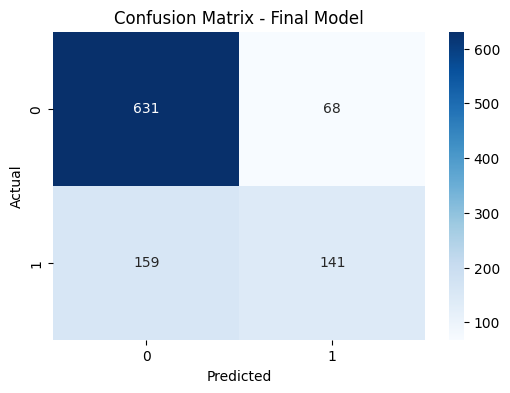

Confusion Matrix Analysis:
True Negatives: 631 (Correctly predicted flops)
False Positives: 68 (Wrongly predicted hits)
False Negatives: 159 (Missed hits)
True Positives: 141 (Correctly predicted hits)


In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Final Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print("Confusion Matrix Analysis:")
print(f"True Negatives: {cm[0,0]} (Correctly predicted flops)")
print(f"False Positives: {cm[0,1]} (Wrongly predicted hits)")
print(f"False Negatives: {cm[1,0]} (Missed hits)")
print(f"True Positives: {cm[1,1]} (Correctly predicted hits)")